https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_xenium.html

# Analyze Xenium data

## Load dataset and get an overview

In [2]:
import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [ ]:
import os
zarr_path = os.path.join("..", "datasets", "xenium.zarr")

In [4]:
sdata = sd.read_zarr(zarr_path)
sdata

version mismatch: detected: RasterFormatV02, requested: FormatV04


c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\zarr\creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compres

SpatialData object, with associated Zarr store: C:\RebEll\Computer\BioinformatikMaster\Semester8\MaPra\datasets\xenium.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 40869, 48326), (1, 20434, 24163), (1, 10217, 12081), (1, 5108, 6040), (1, 2554, 3020)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (40869, 48326), (20434, 24163), (10217, 12081), (5108, 6040), (2554, 3020)
│     └── 'nucleus_labels': DataTree[yx] (40869, 48326), (20434, 24163), (10217, 12081), (5108, 6040), (2554, 3020)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (189598, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (189598, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (189598, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (189598, 280)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_la

In [5]:
adata = sdata.tables["table"]
adata

AnnData object with n_obs × n_vars = 189598 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [6]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
0,aaaadjeh-1,243,0,0,1,0,244,105.214066,66.199065,cell_circles,9.0,1.0,1
1,aaaafmll-1,295,0,0,1,0,296,100.111410,39.105314,cell_circles,9.0,1.0,2
2,aaaahcpb-1,207,0,0,0,0,207,69.901878,31.112657,cell_circles,10.0,1.0,3
3,aaaaibfe-1,140,0,0,0,0,140,48.768752,15.985313,cell_circles,8.0,1.0,4
4,aaaajcfe-1,235,0,0,0,0,235,109.549066,43.937033,cell_circles,8.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189593,oilfamde-1,144,0,0,0,0,144,121.380004,47.097970,cell_circles,7.0,1.0,189594
189594,oilfccnd-1,441,2,0,0,0,443,278.930166,147.390005,cell_circles,7.0,1.0,189595
189595,oilfhkkg-1,187,0,0,1,0,188,79.836253,50.168596,cell_circles,7.0,1.0,189596
189596,oilgaoff-1,158,1,0,0,0,159,162.472193,55.677658,cell_circles,7.0,1.0,189597


In [7]:
adata.obsm["spatial"]

array([[1033.86291504, 2238.22485352],
       [1035.94763184, 2229.7277832 ],
       [1026.84680176, 2233.92773438],
       ...,
       [3430.29296875, 5128.65429688],
       [3437.11694336, 5115.06982422],
       [3425.76123047, 5123.17285156]], shape=(189598, 2))

## Calculate quality control metrics

In [8]:
# Calculate the quality control metrics.

sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

# percentage of control probes and control codewords

cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")


Negative DNA probe count % : 0.13260389546552614
Negative decoding count % : 0.004288590967282994


<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

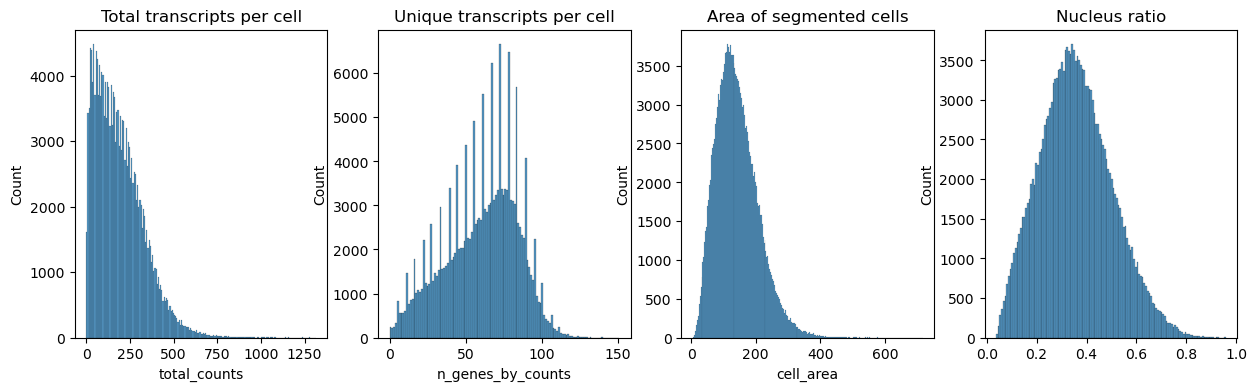

In [9]:
# Plot the distribution of total transcripts per cell, unique transcripts per cell, area of segmented cells and the ratio of nuclei area to their cells.

fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

In [ ]:
# Which parameter should I chose?
sc.pp.filter_cells(adata, min_counts=10) # Filter the cells based on the minimum number of counts required  
sc.pp.filter_genes(adata, min_cells=5) # Filter the genes based on the minimum number of cells required  

# Other filter criteria might be cell area, DAPI signal or a minimum of unique transcripts.

In [11]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, inplace=True) # Normalize counts per cell
sc.pp.log1p(adata) # Logarithmize
sc.pp.pca(adata) # do principal component analysis

In [12]:
sc.pp.neighbors(adata) # compute a neighborhood graph of the observations

c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
sc.tl.umap(adata) # embed the neighborhood graph of the data and cluster the cells into subgroups

In [19]:
adata

AnnData object with n_obs × n_vars = 186606 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [20]:
sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2, directed=False)

C:\Users\rebec\AppData\Local\Temp\ipykernel_1376\2296192396.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2, directed=False)


## Visualize annotation on UMAP and spatial coordinates

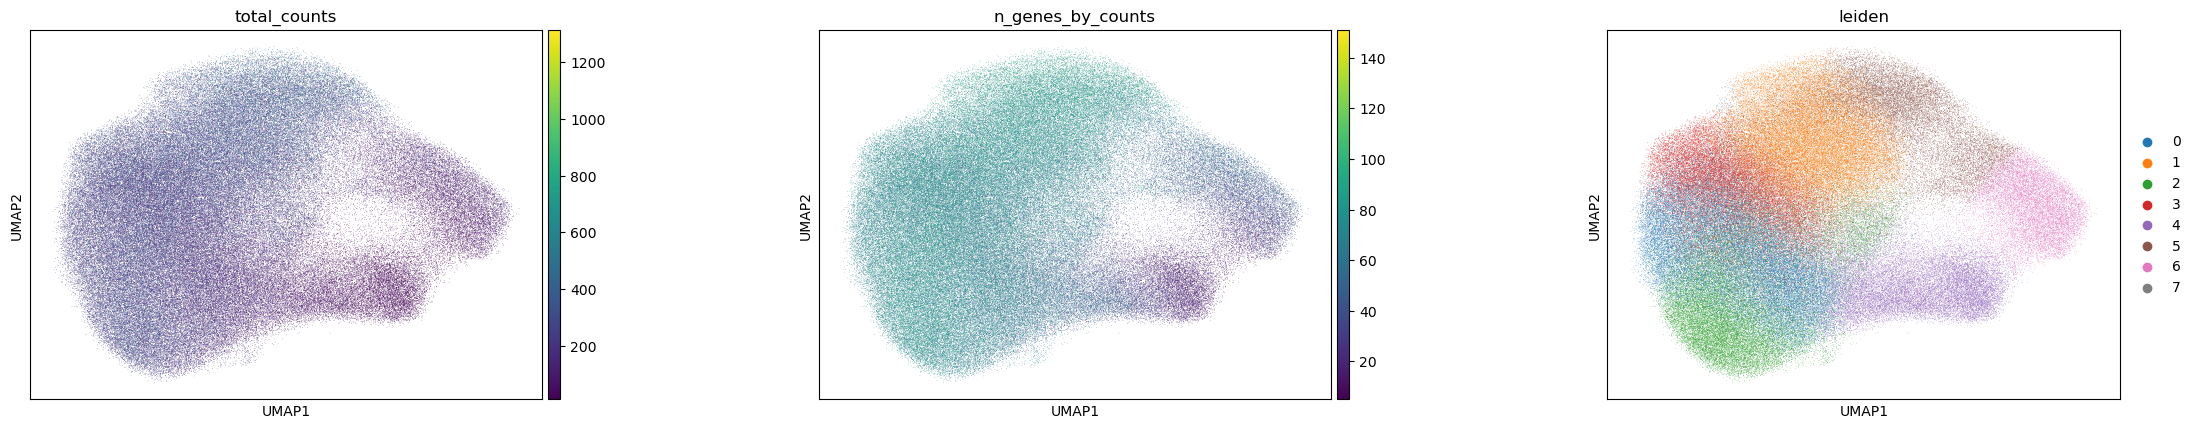

In [21]:
# Subplot with scatter plot in UMAP basis. 
# The embedded points were colored according to the total counts, number of genes by counts, and leiden clusters in each of the subplots. 

sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)


c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\squidpy\pl\_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


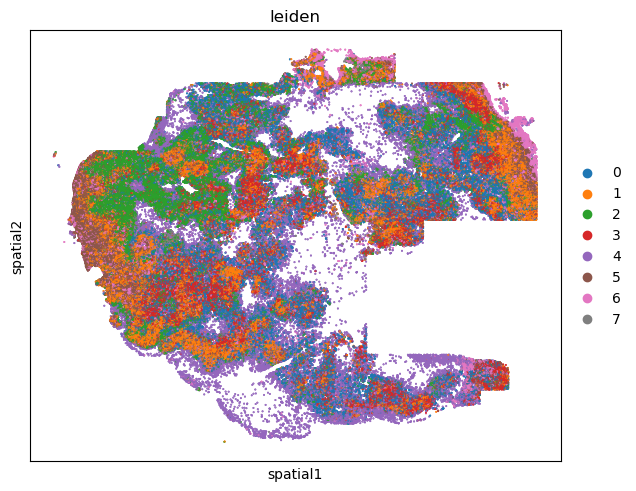

In [22]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

## Computation of spatial statistics

The scores calculated are:

  -  closeness centrality - measure of how close the group is to other nodes.

  -  clustering coefficient - measure of the degree to which nodes cluster together.

  -  degree centrality - fraction of non-group members connected to group members.

All scores are descriptive statistics of the spatial graph.

### Building a spatial neighborhood graph

In [24]:
# Compute a connectivity matrix from spatial coordinates to calculate the centrality scores. 
# We use the coord_type="generic" and the neighbors are classified with Delaunay triangulation.

sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)


### Compute centrality scores

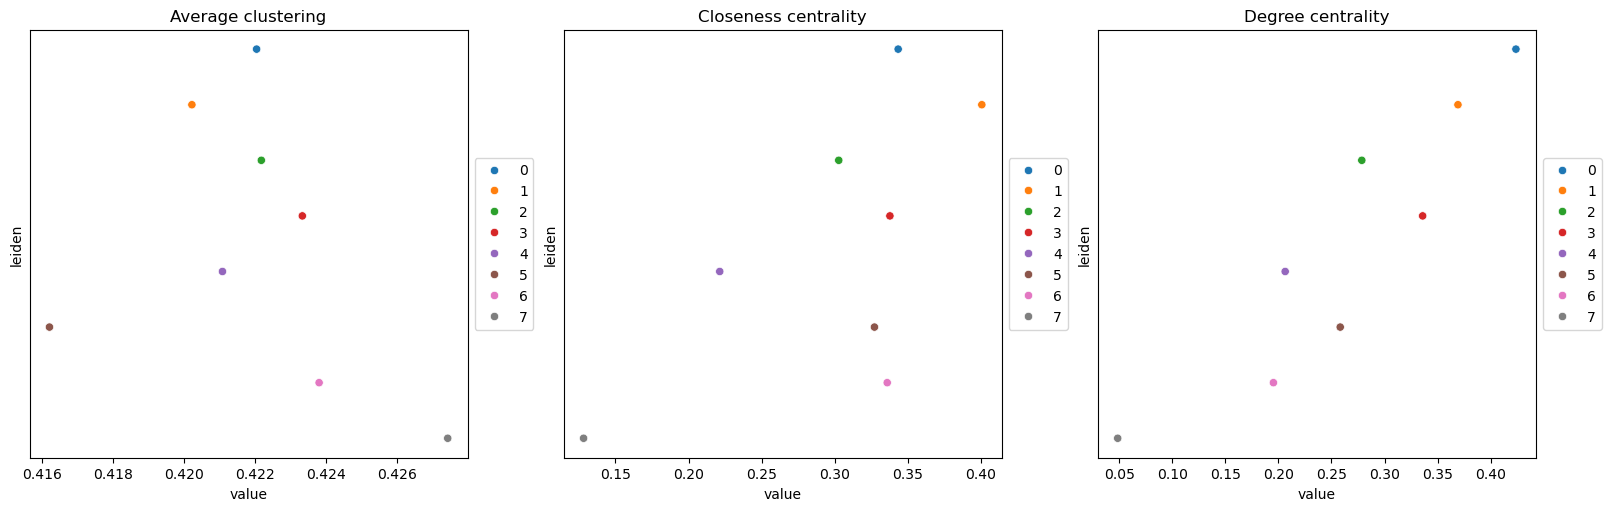

In [25]:
# Calculate centrality scores with the Leiden groups as clusters.

sq.gr.centrality_scores(adata, cluster_key="leiden")

# Visualize the results by plotting the average centrality, closeness centrality, and degree centrality.

sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))


### Compute co-occurrence probability

100%|██████████| 1081/1081 [40:03<00:00,  2.22s/]


c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\squidpy\pl\_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


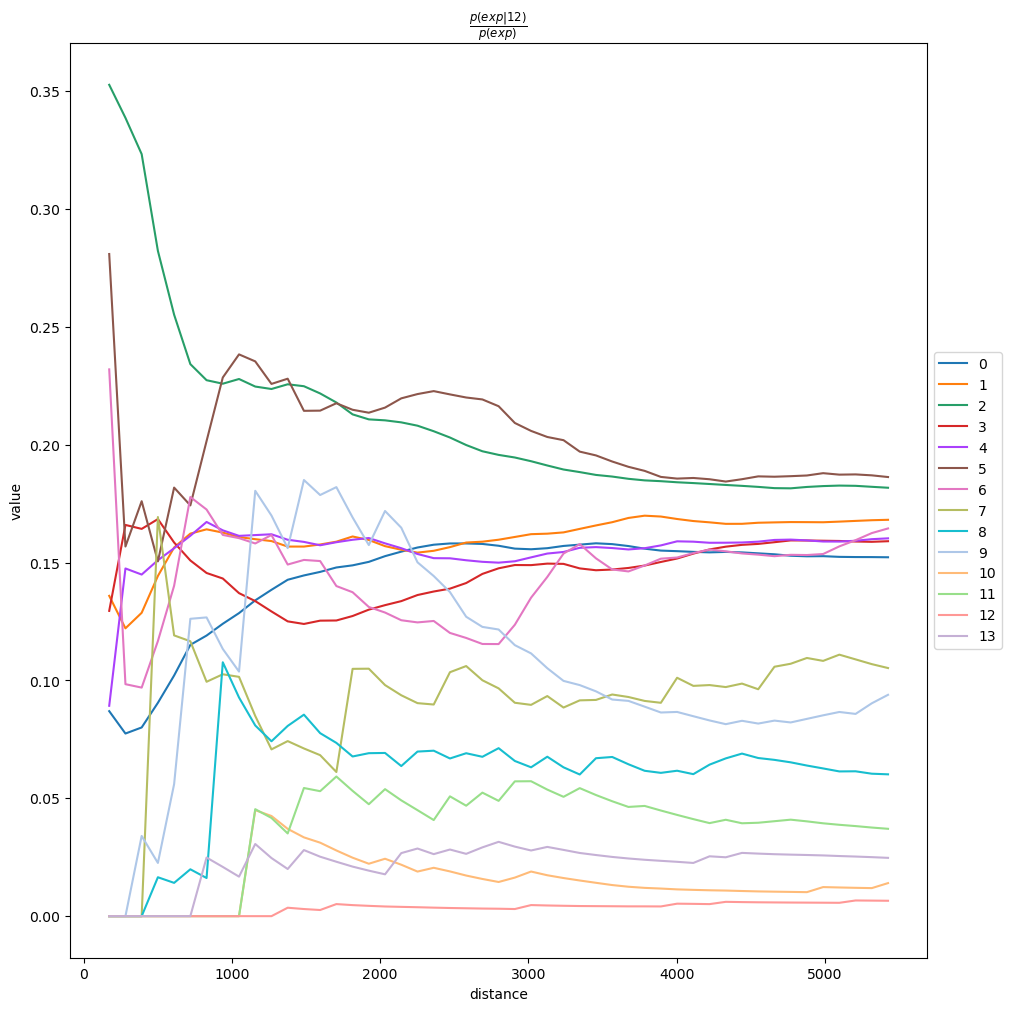

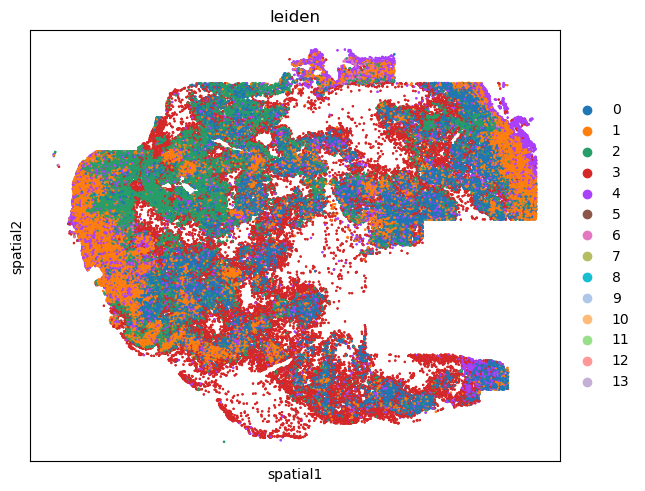

In [ ]:
# First we create a new table, which is a subset of the original Anndata object, and store it in tables.

sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)

# You can also work with sdata.tables["subsample"] directly, but to keep verbosity low, we just use the anndata.Anndata object as before.

adata_subsample = sdata.tables["subsample"]

# Calculate the co-occurrence probability

sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters="12",
    figsize=(10, 10),
)

# Visualize the tissue organization in spatial coordinates, with an overlay of the expressed genes which were colored in consonance with the Leiden clusters.

sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
)


### Neighbors enrichment analysis

It calculates an enrichment score based on proximity on the connectivity graph of cell clusters. The number of observed events is compared against permutations and a z-score is computed.

100%|██████████| 1000/1000 [00:40<00:00, 24.59/s]


c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\squidpy\pl\_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


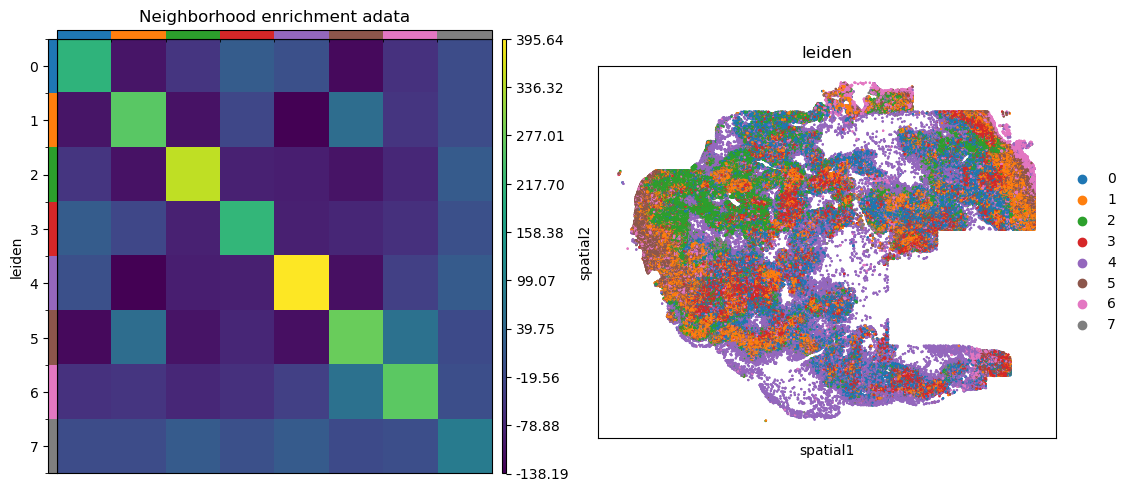

In [27]:
# Calculate the neighborhood enrichment score.

sq.gr.nhood_enrichment(adata, cluster_key="leiden")

# Visualize the results.

fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata, color="leiden", shape=None, size=2, ax=ax[1])


### Compute Moran’s I score and Geary C score

In [17]:
# Compute the Moran’s I global spatial auto-correlation statistics.
# It evaluates whether features (i.e. genes) show a pattern that is clustered, dispersed or random in the tissue.

# We first need to compute a spatial graph.

#sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata.uns["moranI"].head(10)

100%|██████████| 100/100 [07:52<00:00,  4.73s/]


,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
ACTG2,0.440557,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663
SCD,0.404283,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663
SERPINA3,0.379241,0.0,0.000002,0.0,0.009901,0.000003,0.0,0.0,0.010663
KRT7,0.376572,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663
LYZ,0.368525,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663
KRT5,0.363085,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663
SFRP1,0.344447,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663
KRT23,0.337587,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663
TUBB2B,0.314065,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663
DPT,0.294066,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010663


In [18]:
adata

AnnData object with n_obs × n_vars = 186606 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap', 'spatial_neighbors', 'moranI'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'spatial_connectivities', 'spatial_distances'

In [24]:
adata.uns['moranI'].head(10)
adata.uns['spatial_neighbors'].keys()

dict_keys(['connectivities_key', 'distances_key', 'params'])

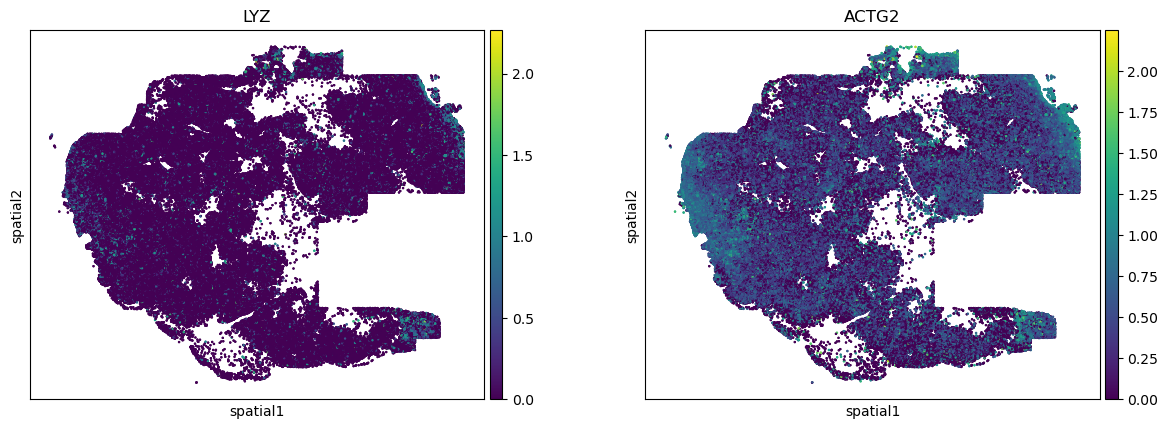

In [ ]:
# Visualize some of those genes.

sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "LYZ",
        "ACTG2",
    ],
    shape=None,
    size=2,
    img=False,
)


In [ ]:
# Compute the Geary’s C statistics.

sq.gr.spatial_autocorr(
    adata,
    mode="geary",
    n_perms=100,
    n_jobs=1,
)
adata.uns["gearyC"].head(10)

100%|██████████| 100/100 [08:53<00:00,  5.34s/]


,C,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
LYZ,0.663665,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010745
ACTG2,0.698806,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010745
SCD,0.718558,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010745
SERPINA3,0.721728,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010745
DPT,0.736114,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010745
KRT5,0.742973,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010745
SFRP1,0.745167,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010745
ZEB2,0.758387,0.0,0.000002,0.0,0.009901,0.000001,0.0,0.0,0.010745
TUBB2B,0.765015,0.0,0.000002,0.0,0.009901,0.000002,0.0,0.0,0.010745
MMP2,0.766489,0.0,0.000002,0.0,0.009901,0.000001,0.0,0.0,0.010745


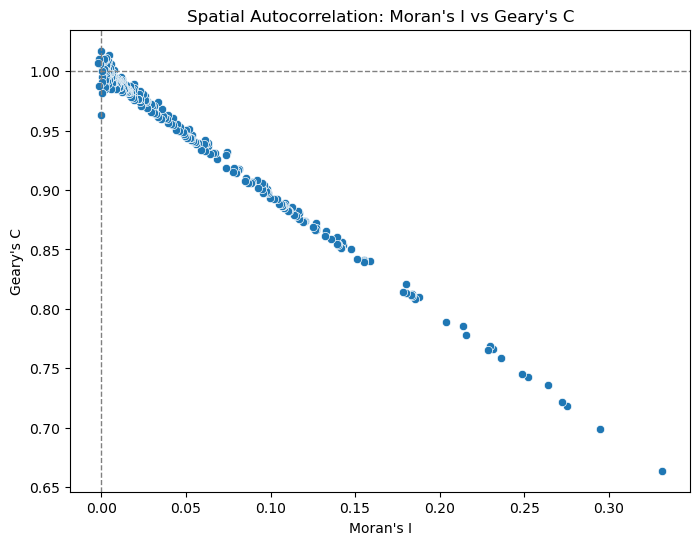

In [ ]:
# Extract results
moran = adata.uns['moranI'].copy()
geary = adata.uns['gearyC'].copy()

# Merge on gene names (index)
df_mg = moran[['I']].rename(columns={'I': 'Moran_I'}).join(geary[['C']].rename(columns={'C': 'Geary_C'}))

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_mg, x='Moran_I', y='Geary_C')
plt.xlabel("Moran's I")
plt.ylabel("Geary's C")
plt.title("Spatial Autocorrelation: Moran's I vs Geary's C")
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(1, color='gray', linestyle='--', linewidth=1)
plt.show()